Saving WhatsApp Image 2026-05-25 at 3.56.06 PM.jpeg to WhatsApp Image 2026-05-25 at 3.56.06 PM.jpeg


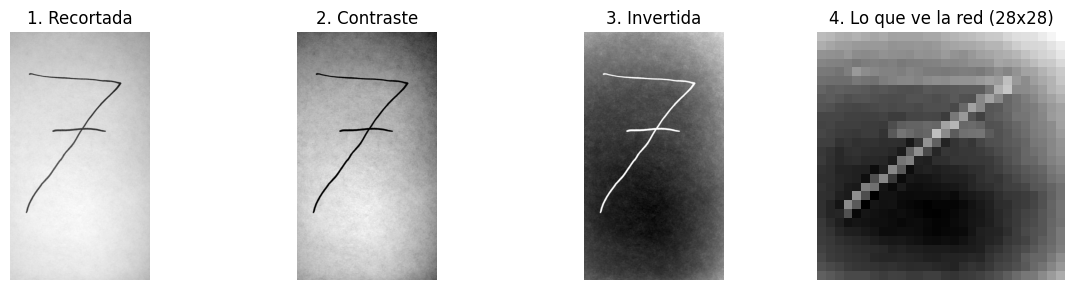

El modelo GPU predice: 7
El modelo CPU predice: 7


In [51]:
from google.colab import files
from PIL import Image, ImageOps
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

def procesar_imagen(nombre):
    original = Image.open(nombre).convert('L')

    # 1. Recortar bordes (quita sombras y bordes de hoja)
    w, h = original.size
    recortada = original.crop((w*0.05, h*0.05, w*0.95, h*0.95))

    # 2. Aumentar contraste para separar trazo del fondo
    from PIL import ImageEnhance, ImageFilter
    contraste = ImageEnhance.Contrast(recortada).enhance(3.0)

    # 3. Suavizar ruido de arrugas
    suavizada = contraste.filter(ImageFilter.MedianFilter(size=3))

    # 4. Invertir colores (fondo negro, trazo blanco como MNIST)
    invertida = ImageOps.invert(suavizada)
    engrosada = invertida.filter(ImageFilter.MaxFilter(size=3))

    # 5. Escalar a 28x28
    procesada = engrosada.resize((28, 28), Image.LANCZOS)

    # Visualizar las etapas
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    axes[0].imshow(recortada, cmap='gray')
    axes[0].set_title('1. Recortada')
    axes[0].axis('off')

    axes[1].imshow(contraste, cmap='gray')
    axes[1].set_title('2. Contraste')
    axes[1].axis('off')

    axes[2].imshow(invertida, cmap='gray')
    axes[2].set_title('3. Invertida')
    axes[2].axis('off')

    axes[3].imshow(np.array(procesada), cmap='gray')
    axes[3].set_title('4. Lo que ve la red (28x28)')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    return procesada

subido = files.upload()
nombre = list(subido.keys())[0]

imagen = procesar_imagen(nombre)

# Pasar al modelo
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

tensor = transform(imagen).unsqueeze(0).to('cuda')

modelo_gpu.eval()
with torch.no_grad():
    salida = modelo_gpu(tensor)
    prediccion = salida.argmax(dim=1).item()

print(f'El modelo GPU predice: {prediccion}')

modelo_cpu.eval()
with torch.no_grad():
    tensor_cpu = transform(imagen).unsqueeze(0).to('cpu')
    salida = modelo_cpu(tensor_cpu)
    prediccion = salida.argmax(dim=1).item()

print(f'El modelo CPU predice: {prediccion}')

In [55]:
# Ver qué tan seguro está cada modelo
import torch.nn.functional as F

with torch.no_grad():
    # GPU
    tensor_gpu = transform(imagen).unsqueeze(0).to('cuda')
    salida_gpu = modelo_gpu(tensor_gpu)
    prob_gpu = F.softmax(salida_gpu, dim=1)[0]

    # CPU
    tensor_cpu = transform(imagen).unsqueeze(0).to('cpu')
    salida_cpu = modelo_cpu(tensor_cpu)
    prob_cpu = F.softmax(salida_cpu, dim=1)[0]

print("Probabilidades GPU:")
for i, p in enumerate(prob_gpu):
    print(f"  {i}: {p.item()*100:.1f}%")

print("\nProbabilidades CPU:")
for i, p in enumerate(prob_cpu):
    print(f"  {i}: {p.item()*100:.1f}%")

Probabilidades GPU:
  0: 0.0%
  1: 3.3%
  2: 0.0%
  3: 0.0%
  4: 0.0%
  5: 0.0%
  6: 0.0%
  7: 96.7%
  8: 0.0%
  9: 0.0%

Probabilidades CPU:
  0: 0.0%
  1: 0.0%
  2: 0.0%
  3: 0.1%
  4: 0.0%
  5: 0.0%
  6: 0.0%
  7: 97.5%
  8: 0.0%
  9: 2.4%


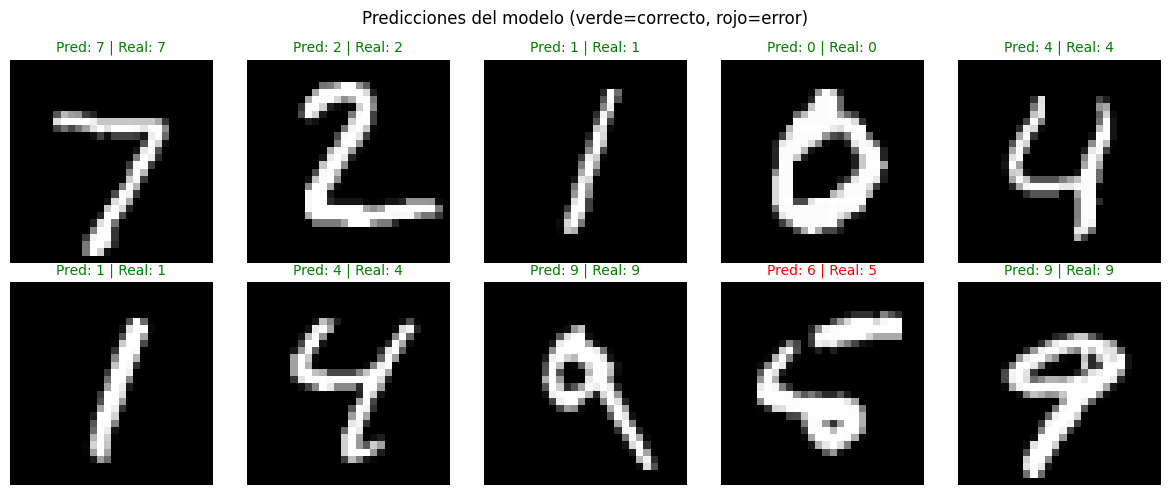

In [54]:
# Celda 14: Visualizar predicciones del modelo GPU
modelo_gpu.eval()
imagenes_test, etiquetas_test = next(iter(test_loader))
imagenes_test = imagenes_test.to('cuda')

with torch.no_grad():
    salidas = modelo_gpu(imagenes_test)
    _, predicciones = torch.max(salidas, 1)

# Traer todo de vuelta a CPU para visualizar
imagenes_test = imagenes_test.cpu()
predicciones  = predicciones.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagenes_test[i].squeeze(), cmap='gray')
    correcto = predicciones[i] == etiquetas_test[i]
    color = 'green' if correcto else 'red'
    ax.set_title(f'Pred: {predicciones[i]} | Real: {etiquetas_test[i]}',
                 color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Predicciones del modelo (verde=correcto, rojo=error)', fontsize=12)
plt.tight_layout()
plt.show()


In [53]:
# Celda 13: Evaluar el modelo entrenado en GPU

def evaluar(modelo, loader, dispositivo):
    modelo.eval()  # Modo evaluacion (desactiva dropout, etc.)
    correctas = 0
    total = 0

    with torch.no_grad():  # No calcular gradientes (ahorra memoria)
        for imagenes, etiquetas in loader:
            imagenes = imagenes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)

            salidas = modelo(imagenes)
            # La prediccion es la clase con mayor valor
            _, prediccion = torch.max(salidas, 1)
            total += etiquetas.size(0)
            correctas += (prediccion == etiquetas).sum().item()

    return 100 * correctas / total

precision_gpu = evaluar(modelo_gpu, test_loader, 'cuda')
precision_cpu = evaluar(modelo_cpu, test_loader, 'cpu')
print(f'Precision del modelo GPU: {precision_gpu:.2f}%')
print(f'Precision del modelo CPU: {precision_cpu:.2f}%')


Precision del modelo GPU: 97.74%
Precision del modelo CPU: 97.13%


In [52]:
# Celda 12: Comparacion CPU vs GPU
print('\n' + '=' * 50)
print('COMPARACION DE RENDIMIENTO')
print('=' * 50)
print(f'Tiempo en CPU:  {tiempo_cpu:.2f} segundos')
print(f'Tiempo en GPU:  {tiempo_gpu:.2f} segundos')
aceleracion = tiempo_cpu / tiempo_gpu
print(f'La GPU fue {aceleracion:.1f}x mas rapida que la CPU')

# Ver memoria de GPU usada durante entrenamiento
print(f'\nMemoria GPU usada: {torch.cuda.max_memory_allocated()/1e6:.1f} MB')
!nvidia-smi



COMPARACION DE RENDIMIENTO
Tiempo en CPU:  54.01 segundos
Tiempo en GPU:  49.59 segundos
La GPU fue 1.1x mas rapida que la CPU

Memoria GPU usada: 24.0 MB
Mon May 25 21:01:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             31W /   70W |     167MiB /  15360MiB |      0%

ENTRENAMIENTO EN GPU
Epoca 1/3 - Train loss: 0.2248 | Test loss: 0.1104
Epoca 2/3 - Train loss: 0.0931 | Test loss: 0.0852
Epoca 3/3 - Train loss: 0.0646 | Test loss: 0.0776


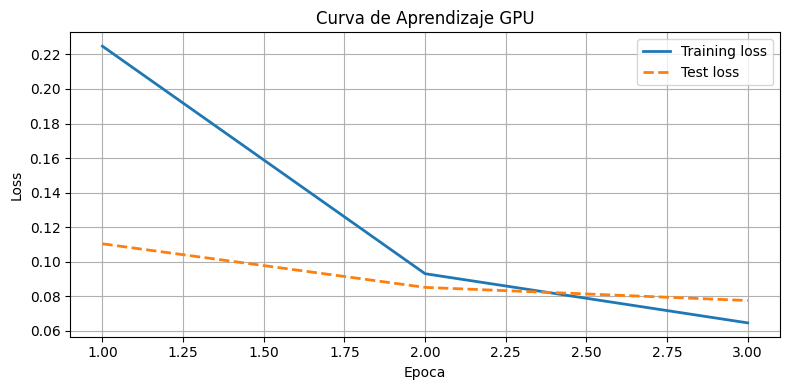

Tiempo total en GPU: 49.59 segundos


In [50]:
# Celda 11: Entrenamiento en GPU

print('=' * 50)
print('ENTRENAMIENTO EN GPU')
print('=' * 50)

# Crear nuevo modelo en GPU
modelo_gpu = RedNeuronal().to('cuda')

# Entrenar y guardar historicos
historico_train_gpu, historico_test_gpu, tiempo_gpu = entrenar_con_loss(
    modelo_gpu,
    train_loader,
    test_loader,
    'cuda',
    'GPU',
    epocas=3
)

print(f'Tiempo total en GPU: {tiempo_gpu:.2f} segundos')

ENTRENAMIENTO EN CPU
Epoca 1/3 - Train loss: 0.2310 | Test loss: 0.1356
Epoca 2/3 - Train loss: 0.0959 | Test loss: 0.0896
Epoca 3/3 - Train loss: 0.0664 | Test loss: 0.0967


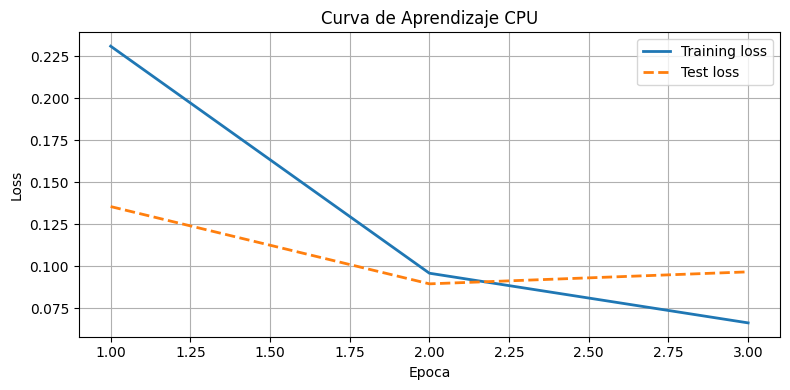

Tiempo total en CPU: 54.01 segundos


In [49]:
# Celda 10: Entrenamiento en CPU

print('=' * 50)
print('ENTRENAMIENTO EN CPU')
print('=' * 50)

# Crear nuevo modelo en CPU
modelo_cpu = RedNeuronal().to('cpu')

# Entrenar y guardar historicos
historico_train_cpu, historico_test_cpu, tiempo_cpu = entrenar_con_loss(
    modelo_cpu,
    train_loader,
    test_loader,
    'cpu',
    'CPU',
    epocas=3
)

print(f'Tiempo total en CPU: {tiempo_cpu:.2f} segundos')

In [48]:
# Celda 9: Funcion de entrenamiento (reutilizable para CPU y GPU)
def entrenar_con_loss(modelo, train_loader, test_loader, dispositivo, title, epocas=3):
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=0.001)

    historico_train = []
    historico_test  = []

    modelo.train()
    inicio = time.time()

    for epoca in range(epocas):
        # --- Training loss ---
        modelo.train()
        loss_train = 0
        for imagenes, etiquetas in train_loader:
            imagenes = imagenes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)

            prediccion = modelo(imagenes)
            perdida = criterio(prediccion, etiquetas)

            optimizador.zero_grad()
            perdida.backward()
            optimizador.step()

            loss_train += perdida.item()

        # --- Test loss ---
        modelo.eval()
        loss_test = 0
        with torch.no_grad():
            for imagenes, etiquetas in test_loader:
                imagenes = imagenes.to(dispositivo)
                etiquetas = etiquetas.to(dispositivo)
                prediccion = modelo(imagenes)
                perdida = criterio(prediccion, etiquetas)
                loss_test += perdida.item()

        avg_train = loss_train / len(train_loader)
        avg_test  = loss_test  / len(test_loader)

        historico_train.append(avg_train)
        historico_test.append(avg_test)

        print(f"Epoca {epoca+1}/{epocas} - Train loss: {avg_train:.4f} | Test loss: {avg_test:.4f}")

    tiempo = time.time() - inicio

    # --- Graficar ---
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epocas+1), historico_train, label='Training loss', linewidth=2)
    plt.plot(range(1, epocas+1), historico_test,  label='Test loss',     linewidth=2, linestyle='--')
    plt.xlabel('Epoca')
    plt.ylabel('Loss')
    plt.title(f'Curva de Aprendizaje {title}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return historico_train, historico_test, tiempo

In [47]:
# Celda 8: Definir la arquitectura de la red neuronal

class RedNeuronal(nn.Module):
    def __init__(self):
        super(RedNeuronal, self).__init__()
        # Definir las capas de la red
        self.capas = nn.Sequential(
            nn.Flatten(),          # Aplana 28x28 = 784 valores
            nn.Linear(784, 256),   # Capa 1: entrada(784) -> oculta(256)
            nn.ReLU(),             # Funcion de activacion
            nn.Linear(256, 128),   # Capa 2: oculta(256) -> oculta(128)
            nn.ReLU(),             # Funcion de activacion
            nn.Linear(128, 10),    # Capa 3: oculta(128) -> salida(10 digitos)
        )

    def forward(self, x):
        return self.capas(x)

# Crear la red y moverla a la GPU
# Esto es equivalente a cudaMalloc para los pesos de la red
modelo = RedNeuronal().to(device)

print('Arquitectura de la red:')
print(modelo)
print()

# Contar parametros entrenables
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'Total de parametros: {total_params:,}')


Arquitectura de la red:
RedNeuronal(
  (capas): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total de parametros: 235,146


Forma de un lote: torch.Size([64, 1, 28, 28])


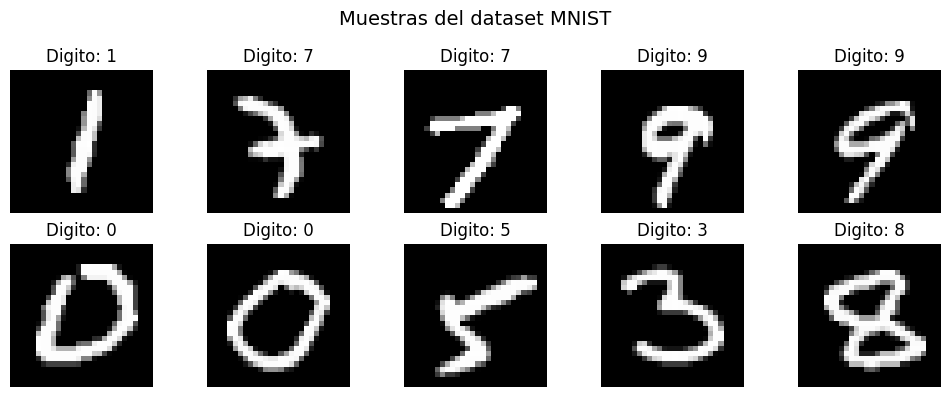

In [45]:
# Celda 7: Ver algunas imagenes del dataset
imagenes, etiquetas = next(iter(train_loader))

print('Forma de un lote:', imagenes.shape)  # [64, 1, 28, 28]
# 64 = batch_size, 1 = canal (escala de grises), 28x28 = tamano imagen

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagenes[i].squeeze(), cmap='gray')
    ax.set_title(f'Digito: {etiquetas[i].item()}')
    ax.axis('off')
plt.suptitle('Muestras del dataset MNIST', fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
# Celda 6: Descargar y preparar los datos

# transform: convierte las imagenes a tensores y las normaliza
# Normalizar significa ajustar los valores para que el entrenamiento sea estable
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # media y desv. estandar de MNIST
])

# Descargar datos de entrenamiento (60,000 imagenes)
train_dataset = datasets.MNIST(root='./data', train=True,
                               download=True, transform=transform)

# Descargar datos de prueba (10,000 imagenes)
test_dataset  = datasets.MNIST(root='./data', train=False,
                               download=True, transform=transform)

# DataLoader: carga los datos en lotes (batches) para entrenar de a poco
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print('Imagenes de entrenamiento:', len(train_dataset))
print('Imagenes de prueba:', len(test_dataset))
print('Lotes de entrenamiento:', len(train_loader))


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]

Imagenes de entrenamiento: 60000
Imagenes de prueba: 10000
Lotes de entrenamiento: 938


In [5]:
# Celda 5: Importar librerias necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# Definir el dispositivo (de la celda anterior)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando dispositivo:', device)


Usando dispositivo: cuda


In [4]:
# Celda 4: Definir dispositivo (SIEMPRE al inicio del proyecto)
import torch

# Esta linea elige GPU si hay, CPU si no hay
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo a usar:', device)

# A partir de aqui, todo se envia a 'device'
# No escribimos 'cuda' directamente, usamos la variable device


Dispositivo a usar: cuda


In [3]:
# Celda 3: Tensores en CPU vs GPU
import torch

# Crear un tensor en CPU (memoria del procesador)
tensor_cpu = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print('Tensor en CPU:', tensor_cpu)
print('Dispositivo:', tensor_cpu.device)   # Debe decir: cpu

# Mover el tensor a la GPU (memoria de la tarjeta grafica)
# Esto es equivalente a cudaMemcpy(CPU -> GPU) del tutorial
tensor_gpu = tensor_cpu.to('cuda')
print('Tensor en GPU:', tensor_gpu)
print('Dispositivo:', tensor_gpu.device)   # Debe decir: cuda:0

# Las operaciones en GPU se ejecutan en paralelo automaticamente
resultado = tensor_gpu * 2
print('Resultado (en GPU):', resultado)
print('Dispositivo resultado:', resultado.device)



Tensor en CPU: tensor([1., 2., 3., 4., 5.])
Dispositivo: cpu
Tensor en GPU: tensor([1., 2., 3., 4., 5.], device='cuda:0')
Dispositivo: cuda:0
Resultado (en GPU): tensor([ 2.,  4.,  6.,  8., 10.], device='cuda:0')
Dispositivo resultado: cuda:0


In [2]:
!nvidia-smi

Mon May 25 19:42:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
# Celda 1: Verificar GPU disponible
import torch

print('Version de PyTorch:', torch.__version__)
print('GPU disponible:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('Nombre de la GPU:', torch.cuda.get_device_name(0))
    print('Memoria total (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print('No hay GPU. Revisa que activaste el acelerador correctamente.')

Version de PyTorch: 2.10.0+cu128
GPU disponible: True
Nombre de la GPU: Tesla T4
Memoria total (GB): 15.64
